<a href="https://colab.research.google.com/github/mikkk04/Arena-Simulations/blob/main/Copy_of_Themora.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load necessary libraries/tools

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import heapq
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
from google.colab import drive
from wordcloud import WordCloud
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.tokenize import word_tokenize
import textwrap
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')


# drive.mount('/content/drive/', force_remount=True)

# df = pd.read_csv('/content/drive/MyDrive/dataset/movie.csv')
# df = pd.DataFrame(df)
# df.head(1000)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

# Sample Data

In [ ]:
df = pd.read_csv("/content/dataset.csv")
df.shape

(2500, 2)

In [ ]:
df

,Essay,Theme
0,"From a multidimensional perspective, Nature de...",Nature
1,An analytical exploration of Nature highlights...,Nature
2,Evaluating Nature requires understanding both ...,Nature
3,Evaluating Nature requires understanding both ...,Nature
4,"Within contemporary discourse, Nature occupies...",Nature
...,...,...
2495,An analytical exploration of AI highlights its...,AI
2496,"Within contemporary discourse, AI occupies a c...",AI
2497,"From a multidimensional perspective, AI demons...",AI
2498,"Within contemporary discourse, AI occupies a c...",AI


In [ ]:
df.columns = df.columns.str.lower()
df.head()

,essay,theme
0,"From a multidimensional perspective, Nature de...",Nature
1,An analytical exploration of Nature highlights...,Nature
2,Evaluating Nature requires understanding both ...,Nature
3,Evaluating Nature requires understanding both ...,Nature
4,"Within contemporary discourse, Nature occupies...",Nature


# Data Preprocessing

In [ ]:
def cleanText(text):
    text = text.lower() # to lower the sentences
    text = re.sub(r'\[.*?\]', '', text) # removing brackets and their content
    text = re.sub(r'\d+', '', text) # removing numbers
    text = re.sub(r'[^a-z\s]', '', text) # removing special characters, keeping only letters and spaces
    return text


def preprocessData(text):
    lemmatizer = WordNetLemmatizer()
    tokens = word_tokenize(text) # tokenization
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words] # remove the  stopping words
    stemmed = [lemmatizer.lemmatize(word) for word in tokens] #lemmatization/stemming
    text = ' '.join(stemmed) # join clear text
    return text

In [ ]:
def dataPreparation(text):
  text = cleanText(text)
  text = preprocessData(text)
  return text

In [ ]:
sample1 = df.iloc[0]
sample1['essay']

'From a multidimensional perspective, Nature demonstrates evolving influence. The concept of sustainable agriculture often intersects with environmental stewardship, which affects public health outcomes. Scholars frequently associate coastal adaptation with systemic developments that determines agricultural productivity. Moreover, ecological resilience contributes significantly as it influences food security. In practical contexts, biodiversity conservation remains essential because it shapes human settlement patterns. The relationship between habitat interdependence and forest regeneration further illustrates how it mitigates disaster risks. Therefore, deeper investigation into Nature remains imperative.'

### Clean text



In [ ]:
dataPreparation(sample1['essay'])

'multidimensional perspective nature demonstrates evolving influence concept sustainable agriculture often intersects environmental stewardship affect public health outcome scholar frequently associate coastal adaptation systemic development determines agricultural productivity moreover ecological resilience contributes significantly influence food security practical context biodiversity conservation remains essential shape human settlement pattern relationship habitat interdependence forest regeneration illustrates mitigates disaster risk therefore deeper investigation nature remains imperative'

### Tokenization

In [ ]:
tokens = word_tokenize(sample1['essay']) # tokenization
text_string = ', '.join(tokens)
wrapped_text = textwrap.fill(text_string, width=80) # Wrap at 80 characters
print(wrapped_text)

From, a, multidimensional, perspective, ,, Nature, demonstrates, evolving,
influence, ., The, concept, of, sustainable, agriculture, often, intersects,
with, environmental, stewardship, ,, which, affects, public, health, outcomes,
., Scholars, frequently, associate, coastal, adaptation, with, systemic,
developments, that, determines, agricultural, productivity, ., Moreover, ,,
ecological, resilience, contributes, significantly, as, it, influences, food,
security, ., In, practical, contexts, ,, biodiversity, conservation, remains,
essential, because, it, shapes, human, settlement, patterns, ., The,
relationship, between, habitat, interdependence, and, forest, regeneration,
further, illustrates, how, it, mitigates, disaster, risks, ., Therefore, ,,
deeper, investigation, into, Nature, remains, imperative, .


### Removing stop words

In [ ]:
stop_words = set(stopwords.words('english'))
tokens = [word for word in tokens if word not in stop_words] # remove the  stopping words
text_string = ', '.join(tokens)
wrapped_text = textwrap.fill(text_string, width=80) # Wrap at 80 characters
print(wrapped_text)

From, multidimensional, perspective, ,, Nature, demonstrates, evolving,
influence, ., The, concept, sustainable, agriculture, often, intersects,
environmental, stewardship, ,, affects, public, health, outcomes, ., Scholars,
frequently, associate, coastal, adaptation, systemic, developments, determines,
agricultural, productivity, ., Moreover, ,, ecological, resilience, contributes,
significantly, influences, food, security, ., In, practical, contexts, ,,
biodiversity, conservation, remains, essential, shapes, human, settlement,
patterns, ., The, relationship, habitat, interdependence, forest, regeneration,
illustrates, mitigates, disaster, risks, ., Therefore, ,, deeper, investigation,
Nature, remains, imperative, .


### Lemmatization

In [ ]:
lemmatizer = WordNetLemmatizer()
stemmed = [lemmatizer.lemmatize(word) for word in tokens]
text_string = ', '.join(stemmed)
wrapped_text = textwrap.fill(text_string, width=80) # Wrap at 80 characters
print(wrapped_text)

From, multidimensional, perspective, ,, Nature, demonstrates, evolving,
influence, ., The, concept, sustainable, agriculture, often, intersects,
environmental, stewardship, ,, affect, public, health, outcome, ., Scholars,
frequently, associate, coastal, adaptation, systemic, development, determines,
agricultural, productivity, ., Moreover, ,, ecological, resilience, contributes,
significantly, influence, food, security, ., In, practical, context, ,,
biodiversity, conservation, remains, essential, shape, human, settlement,
pattern, ., The, relationship, habitat, interdependence, forest, regeneration,
illustrates, mitigates, disaster, risk, ., Therefore, ,, deeper, investigation,
Nature, remains, imperative, .


Parts of Speech (POS)

In [ ]:
text_for_pos = dataPreparation(sample1['essay'])
words_for_pos = word_tokenize(text_for_pos)
pos_tags_result = pos_tag(words_for_pos)

# Format each word/tag pair and join them into a single string
formatted_pos_tags = [f"('{word}' , '{tag}')" for word, tag in pos_tags_result]
pos_tags_string = ', '.join(formatted_pos_tags)

# Wrap the string into a paragraph
wrapped_pos_tags = textwrap.fill(pos_tags_string, width=80)
print(wrapped_pos_tags)

('multidimensional' , 'JJ'), ('perspective' , 'NN'), ('nature' , 'NN'),
('demonstrates' , 'VBZ'), ('evolving' , 'VBG'), ('influence' , 'NN'), ('concept'
, 'NN'), ('sustainable' , 'JJ'), ('agriculture' , 'NN'), ('often' , 'RB'),
('intersects' , 'VBZ'), ('environmental' , 'JJ'), ('stewardship' , 'NN'),
('affect' , 'JJ'), ('public' , 'JJ'), ('health' , 'NN'), ('outcome' , 'NN'),
('scholar' , 'NN'), ('frequently' , 'RB'), ('associate' , 'JJ'), ('coastal' ,
'JJ'), ('adaptation' , 'NN'), ('systemic' , 'JJ'), ('development' , 'NN'),
('determines' , 'VBZ'), ('agricultural' , 'JJ'), ('productivity' , 'NN'),
('moreover' , 'RB'), ('ecological' , 'JJ'), ('resilience' , 'NN'),
('contributes' , 'NNS'), ('significantly' , 'RB'), ('influence' , 'VBP'),
('food' , 'NN'), ('security' , 'NN'), ('practical' , 'JJ'), ('context' , 'NN'),
('biodiversity' , 'NN'), ('conservation' , 'NN'), ('remains' , 'VBZ'),
('essential' , 'JJ'), ('shape' , 'NN'), ('human' , 'JJ'), ('settlement' , 'NN'),
('pattern' , 'NN'), (

In [ ]:
cleaned_df = df.copy()
cleaned_df['essay'] = cleaned_df['essay'].apply(dataPreparation)
cleaned_df.head()

,essay,theme
0,multidimensional perspective nature demonstrat...,Nature
1,analytical exploration nature highlight transf...,Nature
2,evaluating nature requires understanding theor...,Nature
3,evaluating nature requires understanding theor...,Nature
4,within contemporary discourse nature occupies ...,Nature


In [ ]:
cleaned_df = df.copy()
cleaned_df['essay'] = cleaned_df['essay'].apply(dataPreparation)
cleaned_df.head()


,essay,theme
0,multidimensional perspective nature demonstrat...,Nature
1,analytical exploration nature highlight transf...,Nature
2,evaluating nature requires understanding theor...,Nature
3,evaluating nature requires understanding theor...,Nature
4,within contemporary discourse nature occupies ...,Nature


In [ ]:
cleaned_df['Token_count'] = cleaned_df['essay'].apply(lambda x: len(word_tokenize(x)))

print("Overall Token Count Summary:")
print(cleaned_df['Token_count'].describe()[['mean', '50%']])

Overall Token Count Summary:
mean    59.8452
50%     60.0000
Name: Token_count, dtype: float64


In [ ]:
print("\nToken Count Summary by Theme:")
print(cleaned_df.groupby('theme')['Token_count'].describe()[['mean', '50%', 'min', 'max', 'std']])


Token Count Summary by Theme:
            mean   50%   min   max       std
theme                                       
AI        59.592  60.0  57.0  62.0  1.005763
Book      59.030  59.0  57.0  61.0  0.911461
Computer  58.296  58.0  56.0  61.0  0.985051
Nature    61.422  61.0  59.0  64.0  1.063098
Vehicles  60.886  61.0  58.0  63.0  1.048429


In [ ]:
print("\nDetailed Token Count Summary:")
print(cleaned_df['Token_count'].describe()[['mean', '50%', 'min', 'max', 'std']])


Detailed Token Count Summary:
mean    59.845200
50%     60.000000
min     56.000000
max     64.000000
std      1.531984
Name: Token_count, dtype: float64


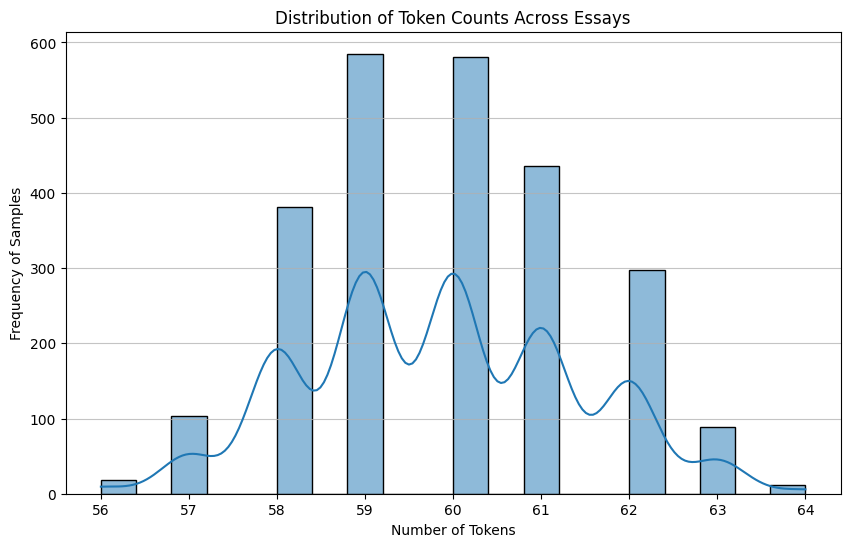

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(cleaned_df['Token_count'], bins=20, kde=True)
plt.title('Distribution of Token Counts Across Essays')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency of Samples')
plt.grid(axis='y', alpha=0.75)
plt.show()

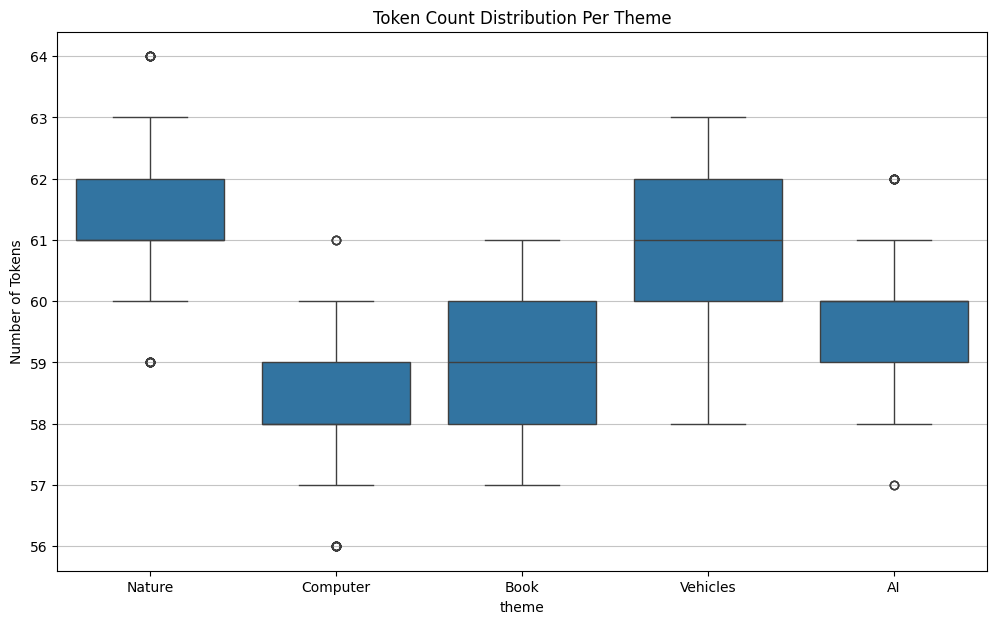

In [ ]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='theme', y='Token_count', data=cleaned_df)
plt.title('Token Count Distribution Per Theme')
plt.xlabel('theme')
plt.ylabel('Number of Tokens')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
cleaned_df['essay']

,essay
0,multidimensional perspective nature demonstrat...
1,analytical exploration nature highlight transf...
2,evaluating nature requires understanding theor...
3,evaluating nature requires understanding theor...
4,within contemporary discourse nature occupies ...
...,...
2495,analytical exploration ai highlight transforma...
2496,within contemporary discourse ai occupies cent...
2497,multidimensional perspective ai demonstrates e...
2498,within contemporary discourse ai occupies cent...


# Feature Extraction

In [ ]:
def vectorize_text(text):
    return text.split(' ')

In [ ]:
q = cleaned_df['essay'][0].split(' ')
r = cleaned_df['essay'][1].split(' ')
q = set(q)
r = set(r)
words_intersection = q.intersection(r) #words that are in both documents

In [ ]:
def term_frequency(essay0, essay1):
    q = set(essay0)
    r = set(essay1)
    # words_intersection = q.union(r) #words

    essay0_words_len = len(essay0)
    essay1_words_len = len(essay1)

    freq_essay0 = {word: essay0.count(word) / essay0_words_len for word in q}
    freq_essay1 = {word: essay1.count(word) / essay1_words_len for word in r}

    return freq_essay0, freq_essay1


In [ ]:
essay_sample = "artificial intelligence ai ha become one of the most transformative force in modern society reshaping industry communication and daily life from personalized recommendation on streaming platform to advanced diagnostic tool in healthcare ai enhances efficiency and enables task that were once impossible for human to perform alone however it rapid development also raise important question about ethic privacy and employment prompting policymakers educator and technologist to carefully consider how ai should be designed and used responsibly despite these challenge ai potential to improve quality of life automate complex process and drive innovation continues to position it a a central pillar of technological progress in the st century"

essay1, essay2 = term_frequency(vectorize_text(essay_sample), vectorize_text(essay_sample))
print(essay1)

{'should': 0.009345794392523364, 'policymakers': 0.009345794392523364, 'continues': 0.009345794392523364, 'industry': 0.009345794392523364, 'consider': 0.009345794392523364, 'communication': 0.009345794392523364, 'these': 0.009345794392523364, 'daily': 0.009345794392523364, 'society': 0.009345794392523364, 'were': 0.009345794392523364, 'also': 0.009345794392523364, 'ai': 0.037383177570093455, 'process': 0.009345794392523364, 'for': 0.009345794392523364, 'development': 0.009345794392523364, 'privacy': 0.009345794392523364, 'however': 0.009345794392523364, 'in': 0.028037383177570093, 'personalized': 0.009345794392523364, 'potential': 0.009345794392523364, 'modern': 0.009345794392523364, 'pillar': 0.009345794392523364, 'once': 0.009345794392523364, 'artificial': 0.009345794392523364, 'innovation': 0.009345794392523364, 'human': 0.009345794392523364, 'streaming': 0.009345794392523364, 'used': 0.009345794392523364, 'efficiency': 0.009345794392523364, 'platform': 0.009345794392523364, 'st': 

In [ ]:
def cosine_similarity(vec1, vec2):
    intersection = set(vec1.keys()) & set(vec2.keys())
    numerator = sum([vec1[x] * vec2[x] for x in intersection])

    sum1 = sum([vec1[x]**2 for x in vec1.keys()])
    sum2 = sum([vec2[x]**2 for x in vec2.keys()])
    denominator = np.sqrt(sum1) * np.sqrt(sum2)

    if not denominator:
        return 0.0
    else:
        return numerator / denominator



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=500) # Limiting to 500 features for better interpretability

# Fit and transform the cleaned essays
tfidf_matrix = tfidf_vectorizer.fit_transform(cleaned_df['essay'])

# Get feature names (words)
feature_names = tfidf_vectorizer.get_feature_names_out()

# Create a DataFrame for TF-IDF scores
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)


# Add the 'Theme' column back to the TF-IDF DataFrame
tfidf_df['theme'] = cleaned_df['theme']

# Group by theme and find top N keywords
top_n_keywords = {}
N = 5 # Number of top keywords to display


for theme in tfidf_df['theme'].unique():
    theme_df = tfidf_df[tfidf_df['theme'] == theme].drop(columns=['theme'])
    # Calculate the sum of TF-IDF scores for each word in the current theme
    word_scores = theme_df.sum().sort_values(ascending=False)
    top_n_keywords[theme] = word_scores.head(N).index.tolist()

# Display the results in a table
keyword_df = pd.DataFrame(top_n_keywords.items(), columns=['Theme', 'Top Keywords'])
keyword_df['Top Keywords'] = keyword_df['Top Keywords'].apply(lambda x: ', '.join(x))
display(keyword_df)

,Theme,Top Keywords
0,Nature,"nature, environmental, livelihood, decision, g..."
1,Computer,"computer, data, strengthens, accelerates, deci..."
2,Book,"book, cultural, intellectual, historical, docu..."
3,Vehicles,"vehicle, supply, chain, integration, facilitates"
4,AI,"ai, adaptive, modeling, predictive, inference"


In [ ]:
random_essay = cleaned_df.sample(n=2, random_state=10)
display(random_essay)

,essay,theme,Token_count
648,multidimensional perspective computer demonstr...,Computer,57
331,critical examination nature reveals structural...,Nature,62


In [ ]:
random_essay['essay']

,essay
648,multidimensional perspective computer demonstr...
331,critical examination nature reveals structural...


In [ ]:
essay1

{'should': 0.009345794392523364,
 'policymakers': 0.009345794392523364,
 'continues': 0.009345794392523364,
 'industry': 0.009345794392523364,
 'consider': 0.009345794392523364,
 'communication': 0.009345794392523364,
 'these': 0.009345794392523364,
 'daily': 0.009345794392523364,
 'society': 0.009345794392523364,
 'were': 0.009345794392523364,
 'also': 0.009345794392523364,
 'ai': 0.037383177570093455,
 'process': 0.009345794392523364,
 'for': 0.009345794392523364,
 'development': 0.009345794392523364,
 'privacy': 0.009345794392523364,
 'however': 0.009345794392523364,
 'in': 0.028037383177570093,
 'personalized': 0.009345794392523364,
 'potential': 0.009345794392523364,
 'modern': 0.009345794392523364,
 'pillar': 0.009345794392523364,
 'once': 0.009345794392523364,
 'artificial': 0.009345794392523364,
 'innovation': 0.009345794392523364,
 'human': 0.009345794392523364,
 'streaming': 0.009345794392523364,
 'used': 0.009345794392523364,
 'efficiency': 0.009345794392523364,
 'platform':

In [ ]:
essay2

{'should': 0.009345794392523364,
 'policymakers': 0.009345794392523364,
 'continues': 0.009345794392523364,
 'industry': 0.009345794392523364,
 'consider': 0.009345794392523364,
 'communication': 0.009345794392523364,
 'these': 0.009345794392523364,
 'daily': 0.009345794392523364,
 'society': 0.009345794392523364,
 'were': 0.009345794392523364,
 'also': 0.009345794392523364,
 'ai': 0.037383177570093455,
 'process': 0.009345794392523364,
 'for': 0.009345794392523364,
 'development': 0.009345794392523364,
 'privacy': 0.009345794392523364,
 'however': 0.009345794392523364,
 'in': 0.028037383177570093,
 'personalized': 0.009345794392523364,
 'potential': 0.009345794392523364,
 'modern': 0.009345794392523364,
 'pillar': 0.009345794392523364,
 'once': 0.009345794392523364,
 'artificial': 0.009345794392523364,
 'innovation': 0.009345794392523364,
 'human': 0.009345794392523364,
 'streaming': 0.009345794392523364,
 'used': 0.009345794392523364,
 'efficiency': 0.009345794392523364,
 'platform':

In [ ]:
import time

start_time = time.time()

random_essay = cleaned_df.sample(n=5, random_state=10)

N = len(random_essay)
correct_theme = 0


for index, row in random_essay.iterrows():
  result = []
  query_essay_vector = vectorize_text(row['essay'])

  random_essays_per_theme = cleaned_df.groupby('theme').sample(n=1)
  for index1, row1 in random_essays_per_theme.iterrows():
    random_essay_text = row1['essay']
    random_essay_vector = vectorize_text(random_essay_text)
    query_essay_freq, random_essay_freq = term_frequency(query_essay_vector, random_essay_vector)
    similarity = cosine_similarity(query_essay_freq, random_essay_freq)
    result.append(similarity)

  random_essays_per_theme['similarity'] = result


  query_theme = row['theme']
  random_theme = random_essays_per_theme.loc[random_essays_per_theme['similarity'].idxmax()]['theme']

  if query_theme == random_theme:
    correct_theme += 1

accuracy = correct_theme / N
accuracy

print(f"Accuracy: {accuracy}")

end_time = time.time()
duration = end_time - start_time
print(f"Processing time: {duration:.2f} seconds")




Accuracy: 1.0
Processing time: 0.04 seconds


In [ ]:
import time

start_time = time.time()
samples = [100, 300, 500, 800, 1000, 1500, 2000, 2500]
accuracy_res = []
duration_res = []
for sample in samples:
  random_essay = cleaned_df.sample(n=sample, random_state=42)

  N = len(random_essay)
  correct_theme = 0


  for index, row in random_essay.iterrows():
    result = []
    query_essay_vector = vectorize_text(row['essay'])

    random_essays_per_theme = cleaned_df.groupby('theme').sample(n=1)
    for index1, row1 in random_essays_per_theme.iterrows():
      random_essay_text = row1['essay']
      random_essay_vector = vectorize_text(random_essay_text)
      query_essay_freq, random_essay_freq = term_frequency(query_essay_vector, random_essay_vector)
      similarity = cosine_similarity(query_essay_freq, random_essay_freq)
      result.append(similarity)

    random_essays_per_theme['similarity'] = result


    query_theme = row['theme']
    random_theme = random_essays_per_theme.loc[random_essays_per_theme['similarity'].idxmax()]['theme']

    if query_theme == random_theme:
      correct_theme += 1

  accuracy = correct_theme / N

  print(f"Accuracy: {accuracy}")

  end_time = time.time()
  duration = end_time - start_time

  print(f"Processing time: {duration:.2f} seconds")

  accuracy_res.append(accuracy)
  duration_res.append(duration)



Accuracy: 1.0
Processing time: 0.37 seconds
Accuracy: 1.0
Processing time: 1.46 seconds
Accuracy: 1.0
Processing time: 3.34 seconds
Accuracy: 1.0
Processing time: 6.38 seconds
Accuracy: 1.0
Processing time: 10.92 seconds
Accuracy: 1.0
Processing time: 16.45 seconds
Accuracy: 1.0
Processing time: 25.36 seconds
Accuracy: 1.0
Processing time: 34.26 seconds


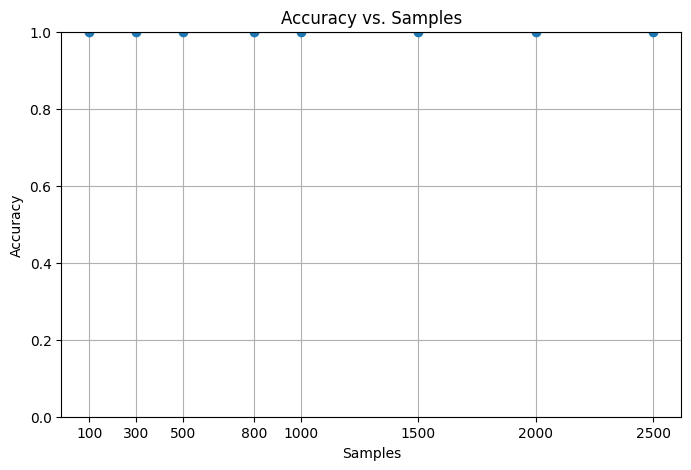

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(samples, accuracy_res, marker='o', linestyle='-')
plt.title('Accuracy vs. Samples')
plt.xlabel('Samples')
plt.ylabel('Accuracy')
plt.xticks(samples)
plt.ylim(0, 1) # Set y-axis limits from 0 to 100
plt.grid(True)
plt.show()

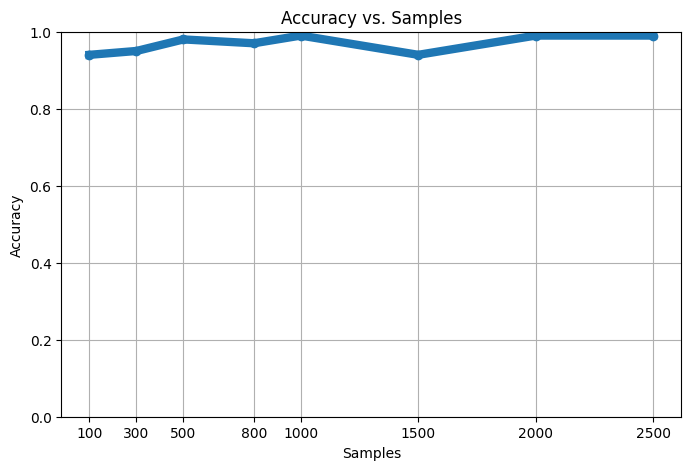

In [ ]:
samples = [100, 300, 500, 800, 1000, 1500, 2000, 2500]
accuracy_res = [.94, .95, .98, .97, .99, .94, .99, .99]
plt.figure(figsize=(8, 5))
plt.plot(samples, accuracy_res, marker='o', linestyle='-', linewidth=6)
plt.title('Accuracy vs. Samples')
plt.xlabel('Samples')
plt.ylabel('Accuracy')
plt.xticks(samples)
plt.ylim(0, 1) # Set y-axis limits from 0 to 100
plt.grid(True)
plt.show()

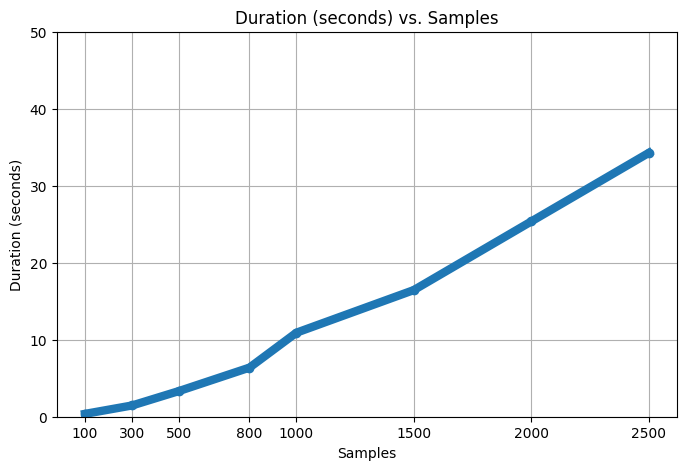

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(samples, duration_res, marker='o', linestyle='-', linewidth=6)
plt.title('Duration (seconds) vs. Samples')
plt.xlabel('Samples')
plt.ylabel('Duration (seconds)')
plt.xticks(samples)
plt.ylim(0, 50) # Set y-axis limits from 0 to 100
plt.grid(True)
plt.show()

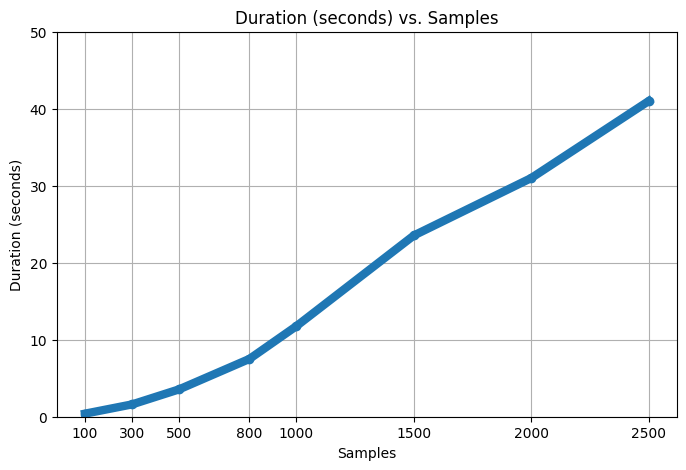

In [ ]:
duration_res = [.4, 1.60, 3.55, 7.51, 11.77, 23.54, 31, 41]
plt.figure(figsize=(8, 5))
plt.plot(samples, duration_res, marker='o', linestyle='-', linewidth=6)
plt.title('Duration (seconds) vs. Samples')
plt.xlabel('Samples')
plt.ylabel('Duration (seconds)')
plt.xticks(samples)
plt.ylim(0, 50) # Set y-axis limits from 0 to 100
plt.grid(True)
plt.show()

Top 10 frequent words: ['development', 'remains', 'concept', 'often', 'intersects', 'scholar', 'frequently', 'associate', 'systemic', 'moreover']


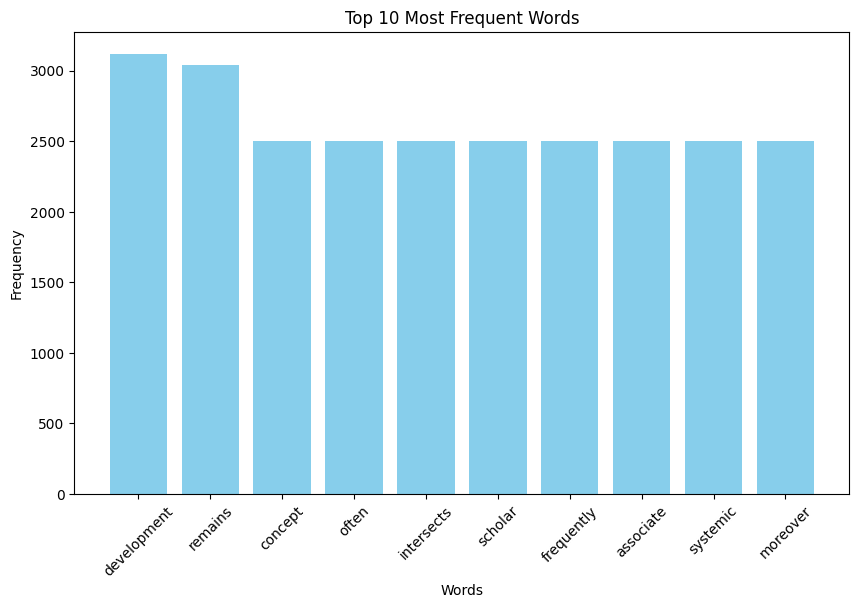

In [ ]:
import collections

all_words = []
for essay in cleaned_df['essay']:
    all_words.extend(essay.split())

wordnet = collections.Counter(all_words)

freq_words = heapq.nlargest(10, wordnet, key=wordnet.get)

print(f"Top 10 frequent words: {freq_words}")

top_words = sorted(wordnet.items(), key=lambda x: x[1], reverse=True)[:10]
words, counts = zip(*top_words)

plt.figure(figsize=(10, 6))
plt.bar(words, counts, color='skyblue')
plt.xticks(rotation=45)
plt.title('Top 10 Most Frequent Words')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.show()

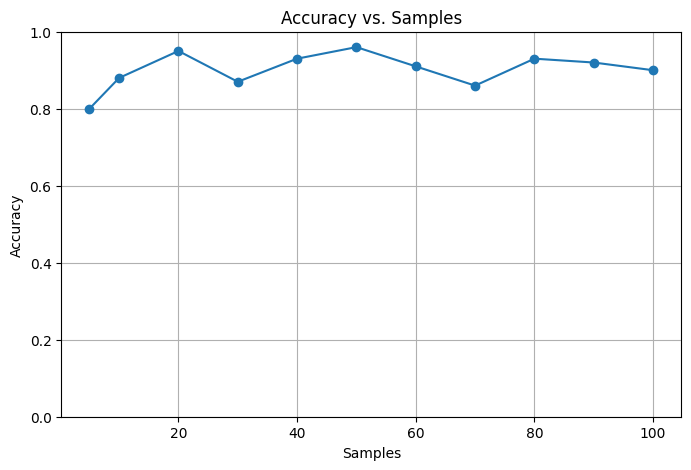

In [ ]:
samples = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
accuracy = [0.80, 0.88, 0.95, 0.87, 0.93, .96, .91, .86, .93, .92, .90]

plt.figure(figsize=(8, 5))
plt.plot(samples, accuracy, marker='o', linestyle='-')
plt.title('Accuracy vs. Samples')
plt.xlabel('Samples')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Set y-axis limits from 0 to 100
plt.grid(True)
plt.show()

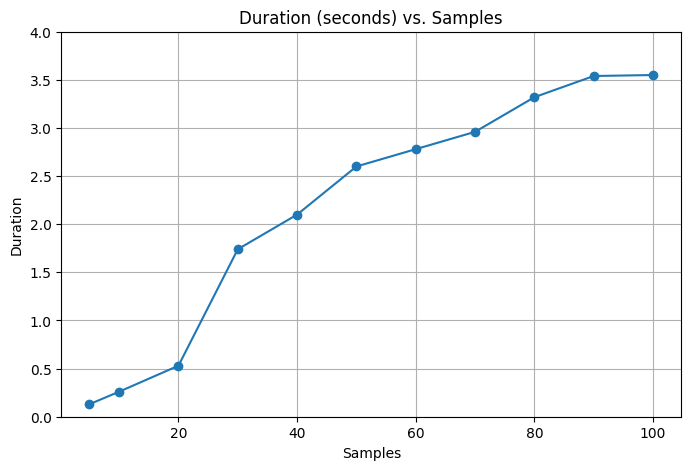

In [ ]:
samples = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
duration = [.13, .26, .53, 1.74, 2.10, 2.60, 2.78, 2.96, 3.32, 3.54, 3.55]

plt.figure(figsize=(8, 5))
plt.plot(samples, duration, marker='o', linestyle='-')
plt.title('Duration (seconds) vs. Samples')
plt.xlabel('Samples')
plt.ylabel('Duration')
plt.ylim(0, 4) # Set y-axis limits from 0 to 100
plt.grid(True)
plt.show()

Starting performance evaluation...
  Query Samples: 100, Ref Samples per Theme: 1 -> Accuracy: 1.0000, Duration: 1.63s
  Query Samples: 100, Ref Samples per Theme: 2 -> Accuracy: 1.0000, Duration: 1.11s
  Query Samples: 100, Ref Samples per Theme: 3 -> Accuracy: 1.0000, Duration: 1.26s
  Query Samples: 100, Ref Samples per Theme: 4 -> Accuracy: 1.0000, Duration: 1.44s
  Query Samples: 100, Ref Samples per Theme: 5 -> Accuracy: 1.0000, Duration: 1.53s
  Query Samples: 300, Ref Samples per Theme: 1 -> Accuracy: 1.0000, Duration: 3.17s
  Query Samples: 300, Ref Samples per Theme: 2 -> Accuracy: 1.0000, Duration: 4.58s
  Query Samples: 300, Ref Samples per Theme: 3 -> Accuracy: 1.0000, Duration: 3.71s
  Query Samples: 300, Ref Samples per Theme: 4 -> Accuracy: 1.0000, Duration: 4.12s
  Query Samples: 300, Ref Samples per Theme: 5 -> Accuracy: 1.0000, Duration: 5.79s
  Query Samples: 500, Ref Samples per Theme: 1 -> Accuracy: 1.0000, Duration: 4.99s
  Query Samples: 500, Ref Samples per The

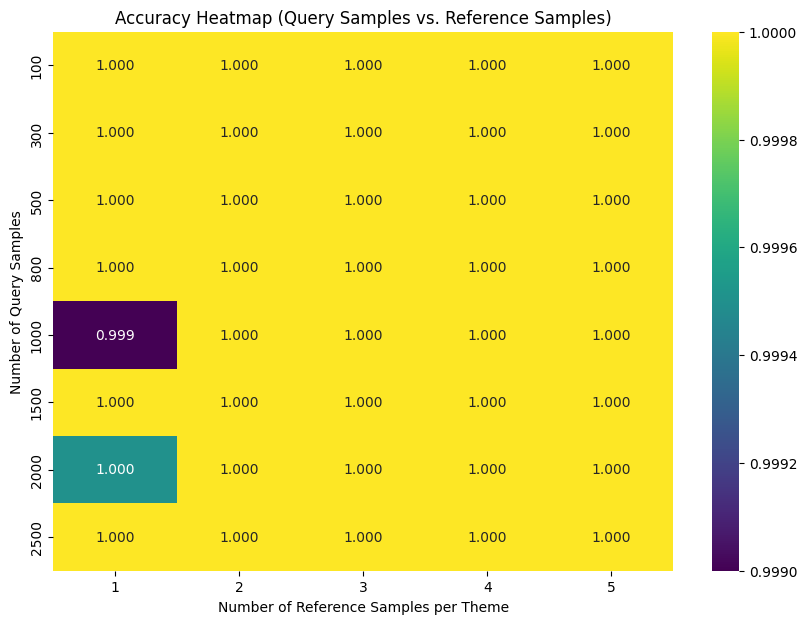

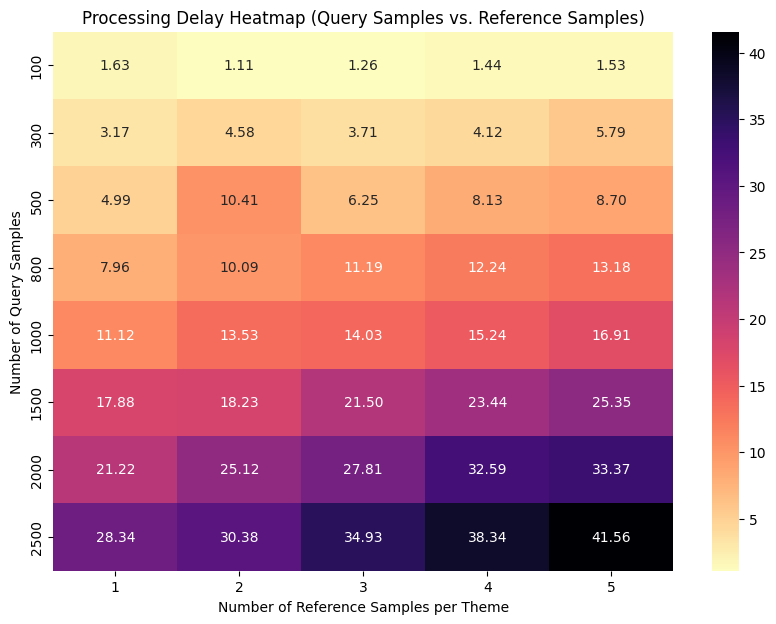

In [ ]:
import time
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Define the range for query samples and reference samples per theme
query_samples_list = [100, 300, 500, 800, 1000, 1500, 2000, 2500]
ref_samples_list = [1, 2, 3, 4, 5] # Number of reference essays to pick per theme

# Initialize matrices to store accuracy and duration results
accuracy_matrix = np.zeros((len(query_samples_list), len(ref_samples_list)))
duration_matrix = np.zeros((len(query_samples_list), len(ref_samples_list)))

print("Starting performance evaluation...")

for i, query_sample_size in enumerate(query_samples_list):
    for j, ref_sample_size in enumerate(ref_samples_list):
        start_time = time.time()

        # Select a subset of essays as query samples
        random_query_essays = cleaned_df.sample(n=query_sample_size, random_state=42)
        N_query = len(random_query_essays)
        correct_theme_count = 0

        # Iterate through each query essay to determine its theme
        for index, query_row in random_query_essays.iterrows():
            query_essay_vector = vectorize_text(query_row['essay'])
            # Calculate term frequencies for the query essay once
            query_essay_freq_dict = term_frequency(query_essay_vector, query_essay_vector)[0]

            theme_similarity_scores = {}
            # For each theme, calculate average similarity with the query essay
            for theme_name in cleaned_df['theme'].unique():
                # Select 'ref_sample_size' essays from the current theme as references
                # Ensure that ref_sample_size does not exceed the number of available essays for the theme
                num_available_for_theme = len(cleaned_df[cleaned_df['theme'] == theme_name])
                actual_ref_sample_size = min(ref_sample_size, num_available_for_theme)

                if actual_ref_sample_size == 0:
                    theme_similarity_scores[theme_name] = 0.0
                    continue

                reference_essays_for_theme = cleaned_df[cleaned_df['theme'] == theme_name].sample(n=actual_ref_sample_size, random_state=j * 100 + i) # Unique random_state for each combination

                current_theme_similarities = []
                for _, ref_row in reference_essays_for_theme.iterrows():
                    ref_essay_vector = vectorize_text(ref_row['essay'])
                    ref_essay_freq_dict = term_frequency(ref_essay_vector, ref_essay_vector)[0]

                    similarity = cosine_similarity(query_essay_freq_dict, ref_essay_freq_dict)
                    current_theme_similarities.append(similarity)

                # Aggregate similarities (using mean) for the current theme
                if current_theme_similarities:
                    theme_similarity_scores[theme_name] = np.mean(current_theme_similarities)
                else:
                    theme_similarity_scores[theme_name] = 0.0

            # Predict the theme based on the highest similarity score
            if theme_similarity_scores:
                predicted_theme = max(theme_similarity_scores, key=theme_similarity_scores.get)
            else:
                predicted_theme = "None" # Fallback if no scores are calculated

            if query_row['theme'] == predicted_theme:
                correct_theme_count += 1

        # Calculate accuracy and duration for the current combination
        accuracy = correct_theme_count / N_query if N_query > 0 else 0.0
        end_time = time.time()
        duration = end_time - start_time

        accuracy_matrix[i, j] = accuracy
        duration_matrix[i, j] = duration

        print(f"  Query Samples: {query_sample_size}, Ref Samples per Theme: {ref_sample_size} -> Accuracy: {accuracy:.4f}, Duration: {duration:.2f}s")

print("Performance evaluation complete. Generating heatmaps...")

# 4.1 Heatmap for Accuracy
plt.figure(figsize=(10, 7))
sns.heatmap(accuracy_matrix, annot=True, fmt=".3f", cmap="viridis",
            xticklabels=ref_samples_list, yticklabels=query_samples_list)
plt.xlabel("Number of Reference Samples per Theme")
plt.ylabel("Number of Query Samples")
plt.title("Accuracy Heatmap (Query Samples vs. Reference Samples)")
plt.show()

# 4.2 Heatmap for Processing Delay
plt.figure(figsize=(10, 7))
sns.heatmap(duration_matrix, annot=True, fmt=".2f", cmap="magma_r",
            xticklabels=ref_samples_list, yticklabels=query_samples_list)
plt.xlabel("Number of Reference Samples per Theme")
plt.ylabel("Number of Query Samples")
plt.title("Processing Delay Heatmap (Query Samples vs. Reference Samples)")
plt.show()

In [ ]:
import time

start_time = time.time()
samples = [1]
accuracy_res = []
duration_res = []
for sample in samples:
  random_essay = cleaned_df.sample(n=sample, random_state=42)
  print(f"Essay theme: {random_essay.iloc[0]['theme']}")
  N = len(random_essay)
  correct_theme = 0


  for index, row in random_essay.iterrows():
    result = []
    query_essay_vector = vectorize_text(row['essay'])

    random_essays_per_theme = cleaned_df.groupby('theme').sample(n=1)
    for index1, row1 in random_essays_per_theme.iterrows():
      random_essay_text = row1['essay']
      random_essay_vector = vectorize_text(random_essay_text)
      query_essay_freq, random_essay_freq = term_frequency(query_essay_vector, random_essay_vector)
      similarity = cosine_similarity(query_essay_freq, random_essay_freq)
      result.append(similarity)
      print(f"{row1['theme']} : {similarity}")

    random_essays_per_theme['similarity'] = result


    query_theme = row['theme']
    random_theme = random_essays_per_theme.loc[random_essays_per_theme['similarity'].idxmax()]['theme']

    if query_theme == random_theme:
      correct_theme += 1

  accuracy = correct_theme / N

  # print(f"Accuracy: {accuracy}")

  end_time = time.time()
  duration = end_time - start_time

  # print(f"Processing time: {duration:.2f} seconds")

  accuracy_res.append(accuracy)
  duration_res.append(duration)



Essay theme: Book
AI : 0.3178208630818641
Book : 0.6203228069323139
Computer : 0.30535240827622967
Nature : 0.27372861697176193
Vehicles : 0.32839478871459266
